# xView2 CNN Project

### Imports; Download Data

In [ ]:
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import manual_seed as torch_manual_seed
from torch.cuda import max_memory_allocated, set_device, manual_seed_all
from torch.backends import cudnn
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("CUDA device name:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
Torch CUDA version: 12.8
CUDA device name: NVIDIA A100-SXM4-80GB


In [ ]:
def setup_seed(seed):
    torch_manual_seed(seed)
    manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False # I added this one to try and make it deterministic

SEED = 42
setup_seed(SEED)

In [ ]:
# This should download and unzip the data and store it in the content folder during your runtime
# full link: https://drive.google.com/file/d/1kMC2PCTyWoOiL0AItssA7Grh4CSoPO2K/view?usp=sharing
!pip install gdown
!gdown --id 1kMC2PCTyWoOiL0AItssA7Grh4CSoPO2K -O data.zip
!unzip -q data.zip -d /content/data
print("finished unzipping")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1kMC2PCTyWoOiL0AItssA7Grh4CSoPO2K
From (redirected): https://drive.google.com/uc?id=1kMC2PCTyWoOiL0AItssA7Grh4CSoPO2K&confirm=t&uuid=0fc41e1a-53ae-435e-8111-2afb35768439
To: /content/data.zip
100% 7.27G/7.27G [02:44<00:00, 44.1MB/s]
finished unzipping


For Nicholas Thornton to load in the data

In [ ]:
# For Nicholas Thornton to load in the data
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/UVA/DS 6050"
ZIP_PATH = os.path.join(BASE_PATH, "xview2_jpeg.zip")

LOCAL_DATA_PATH = "/content/data"
EXTRACT_PATH = os.path.join(LOCAL_DATA_PATH, "xview2_jpeg")

os.makedirs(LOCAL_DATA_PATH, exist_ok=True)

if not os.path.exists(EXTRACT_PATH):
    !unzip -q "{ZIP_PATH}" -d "{LOCAL_DATA_PATH}"

In [ ]:
print(os.listdir("/content/data"))

### Dataset loader; View Images

In [ ]:
class XView2Dataset(Dataset):
    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir

        # anchor on post-disaster images
        self.files = sorted([
            f.replace("_post_disaster.jpg", "").replace("_post_disaster.png", "")
            for f in os.listdir(image_dir)
            if "_post_disaster" in f
        ])

        self.damage_map = {
            "no-damage": 1,
            "minor-damage": 2,
            "major-damage": 3,
            "destroyed": 4,
            "un-classified": 0   # sets building damage that was not classified to background which is not ideal but works for now
        }

    def __len__(self):
        return len(self.files)

    def _load_image(self, path):
        img = cv2.imread(path)

        # BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # normalize to [0,1]
        img = img.astype(np.float32) / 255.0

        return img

    def _load_post_mask(self, json_path, shape):
        H, W = shape
        mask = np.zeros((H, W), dtype=np.uint8)

        with open(json_path) as f:
            data = json.load(f)

        for feature in data["features"]["xy"]:
            props = feature["properties"]

            if "subtype" not in props:
                continue

            damage = props["subtype"]
            class_id = self.damage_map[damage]

            wkt = feature["wkt"]
            coords = wkt.replace("POLYGON ((", "").replace("))", "")

            points = []
            for pair in coords.split(","):
                x, y = map(float, pair.strip().split())
                points.append([int(x), int(y)])

            pts = np.array(points, dtype=np.int32)
            cv2.fillPoly(mask, [pts], class_id)

        return mask

    def _load_pre_mask(self, json_path, shape):
        H, W = shape
        mask = np.zeros((H, W), dtype=np.uint8)

        with open(json_path) as f:
            data = json.load(f)

        for feature in data["features"]["xy"]:
            wkt = feature["wkt"]
            coords = wkt.replace("POLYGON ((", "").replace("))", "")

            points = []
            for pair in coords.split(","):
                x, y = map(float, pair.strip().split())
                points.append([int(x), int(y)])

            pts = np.array(points, dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)  # binary mask

        return mask

    def __getitem__(self, idx):
        base = self.files[idx]

        # handle jpg or png automatically
        for ext in [".jpg", ".png"]:
            pre_path = os.path.join(self.image_dir, base + "_pre_disaster" + ext)
            post_path = os.path.join(self.image_dir, base + "_post_disaster" + ext)
            if os.path.exists(pre_path):
                break

        pre_img = self._load_image(pre_path)
        post_img = self._load_image(post_path)

        # stack → 6 channels
        image = np.concatenate([pre_img, post_img], axis=2)

        pre_label_path = os.path.join(self.label_dir, base + "_pre_disaster.json")
        post_label_path = os.path.join(self.label_dir, base + "_post_disaster.json")

        pre_mask = self._load_pre_mask(pre_label_path, pre_img.shape[:2])
        post_mask = self._load_post_mask(post_label_path, pre_img.shape[:2])

        # convert to tensors
        image = torch.tensor(image).permute(2, 0, 1).float()

        return {
            "image": image,
            "pre_mask": torch.tensor(pre_mask).long(),
            "post_mask": torch.tensor(post_mask).long()
        }

In [ ]:
base_folder = "/content/data/xview2_jpeg"
dataset = XView2Dataset(base_folder+"/hold/images_jpeg", base_folder+"/hold/labels")
sample = dataset[0]

print(sample["image"].shape)  # should be (6, H, W)
print(sample["post_mask"].shape)   # should be (H, W)
print(sample["post_mask"].unique())  # should show 0–4

torch.Size([6, 1024, 1024])
torch.Size([1024, 1024])
tensor([0, 1, 2, 3, 4])


/tmp/ipykernel_712/866812022.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("jet", 5)


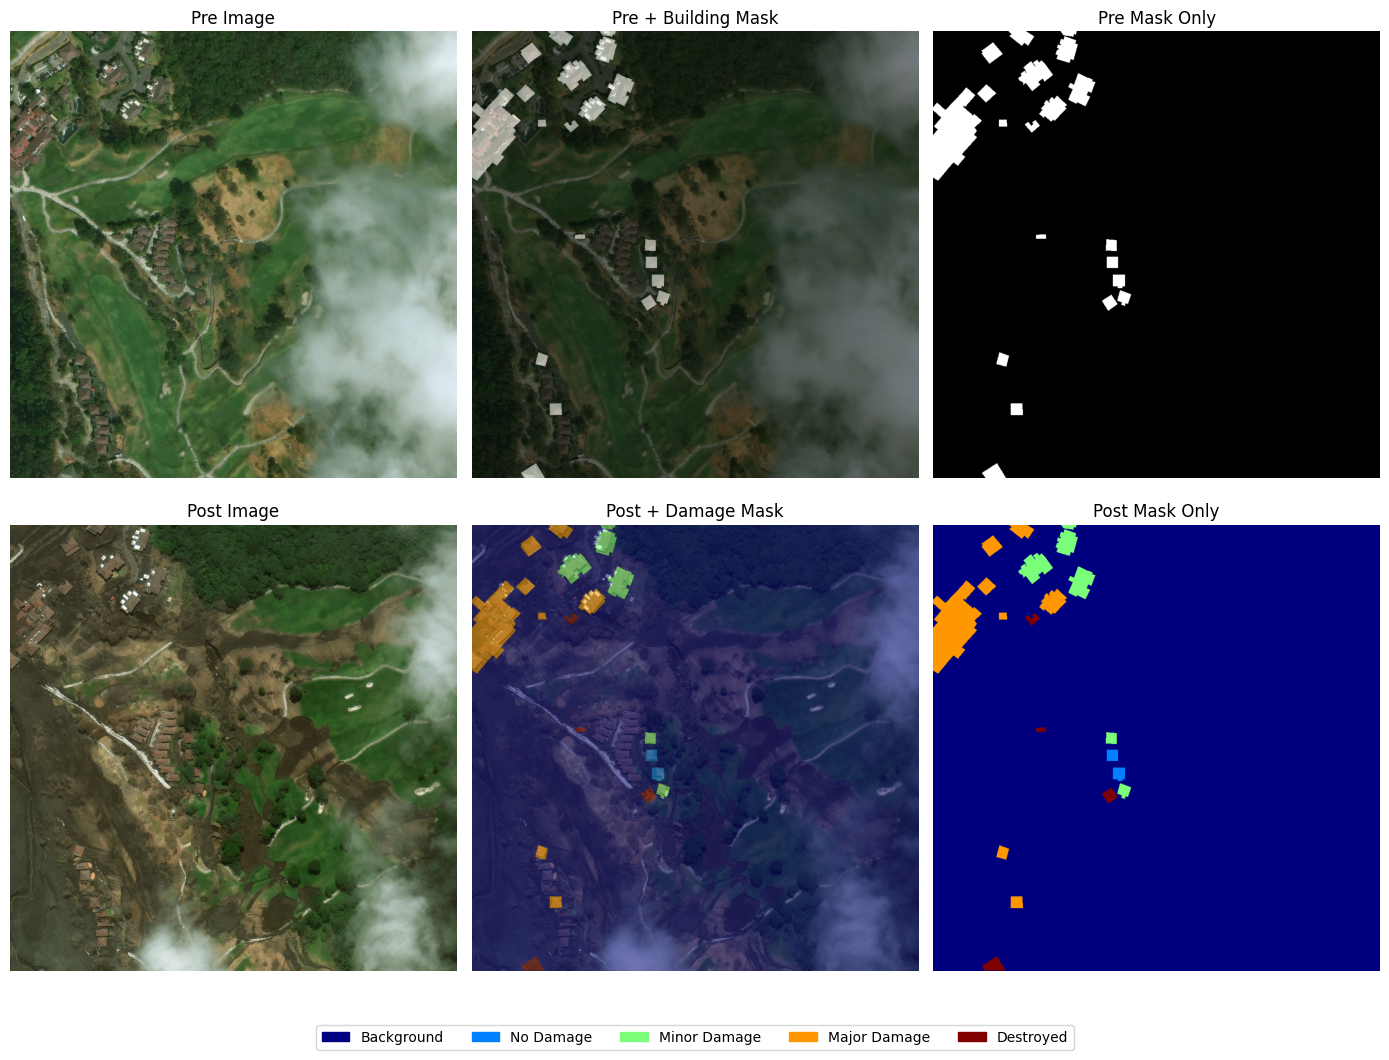

In [ ]:
def visualize_full(sample):
    img = sample["image"]
    pre_mask = sample["pre_mask"].numpy()
    post_mask = sample["post_mask"].numpy()

    pre = img[:3].permute(1,2,0).numpy()
    post = img[3:].permute(1,2,0).numpy()

    cmap = plt.cm.get_cmap("jet", 5)

    fig, axes = plt.subplots(2, 3, figsize=(14, 11))

    # --- PRE ---
    axes[0,0].imshow(pre)
    axes[0,0].set_title("Pre Image")
    axes[0,0].axis("off")

    axes[0,1].imshow(pre)
    axes[0,1].imshow(pre_mask, cmap="gray", alpha=0.5)
    axes[0,1].set_title("Pre + Building Mask")
    axes[0,1].axis("off")

    axes[0,2].imshow(pre_mask, cmap="gray")
    axes[0,2].set_title("Pre Mask Only")
    axes[0,2].axis("off")

    # --- POST ---
    axes[1,0].imshow(post)
    axes[1,0].set_title("Post Image")
    axes[1,0].axis("off")

    axes[1,1].imshow(post)
    axes[1,1].imshow(post_mask, cmap=cmap, alpha=0.5, vmin=0, vmax=4)
    axes[1,1].set_title("Post + Damage Mask")
    axes[1,1].axis("off")

    axes[1,2].imshow(post_mask, cmap=cmap, vmin=0, vmax=4)
    axes[1,2].set_title("Post Mask Only")
    axes[1,2].axis("off")

    # # --- COMPARISON ---
    # axes[2,0].imshow(pre_mask, cmap="gray")
    # axes[2,0].set_title("Buildings")
    # axes[2,0].axis("off")

    # axes[2,1].imshow(post_mask, cmap=cmap, vmin=0, vmax=4)
    # axes[2,1].set_title("Damage Classes")
    # axes[2,1].axis("off")

    # axes[2,2].imshow(pre)
    # axes[2,2].imshow(post_mask, cmap=cmap, alpha=0.5)
    # axes[2,2].set_title("Damage Overlay")
    # axes[2,2].axis("off")

    # --- LEGEND ---
    class_names = [
        "Background",
        "No Damage",
        "Minor Damage",
        "Major Damage",
        "Destroyed"
    ]

    colors = [cmap(i) for i in range(5)]
    patches = [mpatches.Patch(color=colors[i], label=class_names[i]) for i in range(5)]

    fig.legend(
        handles=patches,
        loc="lower center",
        ncol=5,
        bbox_to_anchor=(0.5, 0.02)
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()

sample = dataset[0]
visualize_full(sample)

### DataLoader

In [ ]:
base_folder = "/content/data/xview2_jpeg"

train_dataset = XView2Dataset(base_folder+"/tier1/images_jpeg", base_folder+"/tier1/labels")
val_dataset   = XView2Dataset(base_folder+"/test/images_jpeg", base_folder+"/test/labels")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=1)
val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False)

### Unet Dual-Head Model

Including dual head output: essentially it the model has 2 focuses of both just predicting building location as well as prediction building damage levels. the UNet structure has a single input of the pre and post images concatenated together. I know in our proposal we talked about a Siamese network, but this may be a simpler way to start and something we can compare to more complicated models later.



In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class UNetDualHead(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()

        # Layer feature sizes
        f1 = 32
        f2 = 64
        f3 = 128
        f4 = 256
        f5 = 512

        # Encoder
        self.enc1 = DoubleConv(in_channels, f1)
        self.enc2 = DoubleConv(f1, f2)
        self.enc3 = DoubleConv(f2, f3)
        self.enc4 = DoubleConv(f3, f4)

        # Pooling
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(f4, f5)

        # Decoder
        self.up4 = nn.ConvTranspose2d(f5, f4, 2, stride=2)
        self.dec4 = DoubleConv(f5, f4)

        self.up3 = nn.ConvTranspose2d(f4, f3, 2, stride=2)
        self.dec3 = DoubleConv(f4, f3)

        self.up2 = nn.ConvTranspose2d(f3, f2, 2, stride=2)
        self.dec2 = DoubleConv(f3, f2)

        self.up1 = nn.ConvTranspose2d(f2, f1, 2, stride=2)
        self.dec1 = DoubleConv(f2, f1)

        # final shared features
        self.final_features = nn.Conv2d(f1, f1, kernel_size=1)

        # TWO HEADS
        self.building_head = nn.Conv2d(f1, 1, kernel_size=1)
        self.damage_head = nn.Conv2d(f1, 5, kernel_size=1)

    def forward(self, x):
        # encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # bottleneck
        b = self.bottleneck(self.pool(e4))

        # decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        features = self.final_features(d1)

        building_out = self.building_head(features)
        damage_out = self.damage_head(features)

        return building_out, damage_out


# General Loss Types
bce = nn.BCEWithLogitsLoss()
ce  = nn.CrossEntropyLoss(reduction='none')  # we’ll mask it
def iou_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)

    intersection = (pred * target).sum(dim=(1,2,3))
    union = (pred + target - pred * target).sum(dim=(1,2,3))

    iou = (intersection + smooth) / (union + smooth)
    return 1 - iou.mean()

# Dual Loss
def compute_dual_loss(building_out, damage_out, pre_mask, post_mask):
    # building loss
    loss_b = bce(building_out, pre_mask.unsqueeze(1).float())

    # damage loss (only on buildings)
    mask = (pre_mask > 0)

    loss_d = ce(damage_out, post_mask)  # (B,H,W)
    loss_d = (loss_d * mask).sum() / (mask.sum() + 1e-6)

    return loss_b + loss_d, loss_b, loss_d

### UNet Training

In [ ]:
device_name = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_name)
scaler = torch.amp.GradScaler(device)
model = UNetDualHead(in_channels=6).to(device_name)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        # Move data from the CPU to the GPU
        images = batch["image"].to(device, non_blocking=True)
        pre_mask = batch["pre_mask"].to(device, non_blocking=True)
        post_mask = batch["post_mask"].to(device, non_blocking=True)

        # forward pass
        with torch.amp.autocast(device_type="cuda"):
            building_out, damage_out = model(images)
            loss, l_building, l_damage = compute_dual_loss(building_out, damage_out, pre_mask, post_mask)

        # backpropogation
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

@torch.no_grad()
def validate(loader):
    model.eval()

    total_loss = 0

    for batch in loader:
        # Move data from the CPU to the GPU
        images = batch["image"].to(device, non_blocking=True)
        pre_mask = batch["pre_mask"].to(device, non_blocking=True)
        post_mask = batch["post_mask"].to(device, non_blocking=True)

        # get validation loss
        building_out, damage_out = model(images)
        loss, l_building, l_damage = compute_dual_loss(building_out, damage_out, pre_mask, post_mask)

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
epochs = 10

train_losses = []
val_losses = []

for epoch in range(epochs):
    train_loss = train_one_epoch(train_loader)
    val_loss = validate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

# SegFormer

In [ ]:
# Install required packages (run once if needed)
!pip install transformers timm datasets -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import SegformerForSemanticSegmentation
import numpy as np
from tqdm import tqdm

In [ ]:
NUM_CLASSES = 5  # 0,1,2,3,4

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

In [ ]:
class DisasterDataset(Dataset):
    def __init__(self, pre_images, post_images, masks, transform=None):
        self.pre_images = pre_images
        self.post_images = post_images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.pre_images)

    def __getitem__(self, idx):
        pre = self.pre_images[idx]       # (H, W, 3)
        post = self.post_images[idx]     # (H, W, 3)
        mask = self.masks[idx]           # (H, W)

        # Concatenate pre/post → 6 channels
        image = np.concatenate([pre, post], axis=2)

        # Convert to tensor
        image = torch.tensor(image).permute(2, 0, 1).float()
        mask = torch.tensor(mask).long()

        return image, mask

In [ ]:
# Modify first convolution layer to accept 6 channels
original_conv = model.segformer.encoder.patch_embeddings[0].proj

new_conv = nn.Conv2d(
    in_channels=6,
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding
)

with torch.no_grad():
    new_conv.weight[:, :3] = original_conv.weight
    new_conv.weight[:, 3:] = original_conv.weight
    new_conv.bias = original_conv.bias

model.segformer.encoder.patch_embeddings[0].proj = new_conv
model.to(device)

In [ ]:
# Cross entropy for multi-class segmentation
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

In [ ]:
def compute_metrics(preds, labels, num_classes):
    preds = torch.argmax(preds, dim=1)

    iou_scores = []
    dice_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        label_cls = (labels == cls)

        intersection = (pred_cls & label_cls).sum().item()
        union = (pred_cls | label_cls).sum().item()
        total = pred_cls.sum().item() + label_cls.sum().item()

        if union == 0:
            continue

        iou = intersection / union
        dice = (2 * intersection) / total if total > 0 else 0

        iou_scores.append(iou)
        dice_scores.append(dice)

    return np.mean(iou_scores), np.mean(dice_scores)

In [ ]:
def compute_f1(preds, labels, num_classes):
    preds = torch.argmax(preds, dim=1)

    f1_scores = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        label_cls = (labels == cls)

        tp = (pred_cls & label_cls).sum().item()
        fp = (pred_cls & ~label_cls).sum().item()
        fn = (~pred_cls & label_cls).sum().item()

        denom = (2 * tp + fp + fn)

        if denom == 0:
            continue

        f1 = (2 * tp) / denom
        f1_scores.append(f1)

    return np.mean(f1_scores)

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        images = batch["image"].to(device)
        masks = batch["post_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=images)
        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    all_iou = []
    all_dice = []
    all_f1 = []

    with torch.no_grad():
        for batch in tqdm(loader):
            images = batch["image"].to(device)
            masks = batch["post_mask"].to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(logits, masks)
            total_loss += loss.item()

            iou, dice = compute_metrics(logits, masks, NUM_CLASSES)
            f1 = compute_f1(logits, masks, NUM_CLASSES)

            all_iou.append(iou)
            all_dice.append(dice)
            all_f1.append(f1)

    return (
        total_loss / len(loader),
        np.mean(all_iou),
        np.mean(all_dice),
        np.mean(all_f1)
    )

In [ ]:
batch = next(iter(train_loader))
print(batch.keys())

In [ ]:
batch = next(iter(train_loader))
masks = batch["post_mask"]
print(torch.unique(masks))

In [ ]:
train_losses = []
val_losses = []
val_ious = []
val_dices = []
val_f1s = []

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_iou, val_dice, val_f1 = validate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_iou)
    val_dices.append(val_dice)
    val_f1s.append(val_f1)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val IoU: {val_iou:.4f}")
    print(f"Val Dice: {val_dice:.4f}")
    print(f"Val F1: {val_f1:.4f}")

In [ ]:
best_epoch = val_ious.index(max(val_ious)) + 1
print(f"Best Epoch (IoU): {best_epoch}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Train Loss": train_losses,
    "Val Loss": val_losses,
    "Val IoU": val_ious,
    "Val Dice": val_dices,
    "Val F1": val_f1s
})

results_df.round(4)

In [ ]:
results_df.to_csv("segformer_training_results.csv", index=False)

In [ ]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss")
plt.legend()

plt.subplot(2,2,2)
plt.plot(val_ious)
plt.title("Validation IoU")

plt.subplot(2,2,3)
plt.plot(val_dices)
plt.title("Validation Dice")

plt.subplot(2,2,4)
plt.plot(val_f1s)
plt.title("Validation F1")

plt.tight_layout()
plt.show()

In [ ]:
def compute_per_class_iou_dice(logits, labels, num_classes):
    preds = torch.argmax(logits, dim=1)

    per_class_iou = []
    per_class_dice = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        label_cls = (labels == cls)

        intersection = (pred_cls & label_cls).sum().item()
        union = (pred_cls | label_cls).sum().item()

        iou = intersection / (union + 1e-8)
        dice = (2 * intersection) / (
            pred_cls.sum().item() + label_cls.sum().item() + 1e-8
        )

        per_class_iou.append(iou)
        per_class_dice.append(dice)

    return per_class_iou, per_class_dice

In [ ]:
model.eval()

batch = next(iter(val_loader))
images = batch["image"].to(device)
masks = batch["post_mask"].to(device)

with torch.no_grad():
    outputs = model(pixel_values=images)
    logits = outputs.logits

    # Resize to match mask resolution
    logits = torch.nn.functional.interpolate(
        logits,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

per_class_iou, per_class_dice = compute_per_class_iou_dice(
    logits, masks, NUM_CLASSES
)

In [ ]:
class_names = ["No Damage", "Minor", "Major", "Destroyed", "Background"]

pd.DataFrame({
    "Class": class_names,
    "IoU": per_class_iou,
    "Dice": per_class_dice
})

In [ ]:
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(images[0][:3].cpu().permute(1,2,0))
plt.title("Pre Image")

plt.subplot(1,4,2)
plt.imshow(images[0][3:6].cpu().permute(1,2,0))
plt.title("Post Image")

plt.subplot(1,4,3)
plt.imshow(masks[0].cpu())
plt.title("Ground Truth")

plt.subplot(1,4,4)
plt.imshow(preds[0].cpu())
plt.title("Prediction")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torch.nn.functional as F

model.eval()

batch = next(iter(val_loader))
images = batch["image"].to(device)
masks = batch["post_mask"].to(device)

with torch.no_grad():
    outputs = model(pixel_values=images)
    logits = outputs.logits

    # 🔥 Resize to mask resolution
    logits = F.interpolate(
        logits,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

    preds = torch.argmax(logits, dim=1)

preds_flat = preds.cpu().numpy().flatten()
masks_flat = masks.cpu().numpy().flatten()

cm = confusion_matrix(masks_flat, preds_flat)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Pixel Confusion Matrix")
plt.show()

In [ ]:
plt.plot(val_ious)
plt.axvline(best_epoch-1, color='r', linestyle='--')
plt.title("Validation IoU with Best Epoch")
plt.show()

In [ ]:
def compute_per_class_metrics(logits, labels, num_classes):
    preds = torch.argmax(logits, dim=1)

    per_class_metrics = []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        label_cls = (labels == cls)

        tp = (pred_cls & label_cls).sum().item()
        fp = (pred_cls & ~label_cls).sum().item()
        fn = (~pred_cls & label_cls).sum().item()

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        iou = tp / (tp + fp + fn + 1e-8)
        dice = 2 * tp / (2 * tp + fp + fn + 1e-8)

        per_class_metrics.append({
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "IoU": iou,
            "Dice": dice
        })

    return per_class_metrics

In [ ]:
metrics = compute_per_class_metrics(logits, masks, NUM_CLASSES)

pd.DataFrame(metrics, index=class_names).round(4)

In [ ]:
unique, counts = torch.unique(masks, return_counts=True)

class_distribution = pd.DataFrame({
    "Class": unique.cpu().numpy(),
    "Pixel Count": counts.cpu().numpy()
})

class_distribution

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

full_counts = torch.zeros(NUM_CLASSES)

unique, counts = torch.unique(masks, return_counts=True)

for u, c in zip(unique, counts):
    full_counts[u] = c

plt.bar(class_names, full_counts.cpu().numpy())
plt.xticks(rotation=45)
plt.title("Pixel Distribution Per Class")
plt.show()

In [ ]:
error_map = (preds[0] != masks[0]).cpu()

plt.imshow(error_map)
plt.title("Misclassified Pixels")
plt.show()

In [ ]:
minority_classes = ["Major", "Destroyed"]

df = pd.DataFrame(metrics, index=class_names)
df.loc[minority_classes]

In [ ]:
import torch
import pandas as pd
from tqdm import tqdm

def compute_class_distribution(loader, num_classes):
    class_counts = torch.zeros(num_classes)

    for batch in tqdm(loader):
        masks = batch["post_mask"]

        for cls in range(num_classes):
            class_counts[cls] += (masks == cls).sum().item()

    total_pixels = class_counts.sum()
    class_percentages = class_counts / total_pixels

    return class_counts, class_percentages

In [ ]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=NUM_WORKERS
)

In [ ]:
train_counts, train_perc = compute_class_distribution(train_loader, NUM_CLASSES)
val_counts, val_perc = compute_class_distribution(val_loader, NUM_CLASSES)
test_counts, test_perc = compute_class_distribution(test_loader, NUM_CLASSES)

class_names = ["No Damage", "Minor", "Major", "Destroyed", "Background"]

distribution_df = pd.DataFrame({
    "Class": class_names,
    "Train %": train_perc.numpy() * 100,
    "Val %": val_perc.numpy() * 100,
    "Test %": test_perc.numpy() * 100
})

distribution_df.round(2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, train_perc.numpy() * 100, width, label="Train")
plt.bar(x, val_perc.numpy() * 100, width, label="Val")
plt.bar(x + width, test_perc.numpy() * 100, width, label="Test")

plt.xticks(x, class_names, rotation=45)
plt.ylabel("Percentage of Pixels (%)")
plt.title("Class Distribution Across Splits")
plt.legend()
plt.tight_layout()
plt.show()

# New SegFormer

 Install SegFormer Dependencies and Import Libraries

In [ ]:
!pip install transformers timm datasets -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import SegformerForSemanticSegmentation

In [ ]:
NUM_CLASSES = 5
class_names = ["Background", "No Damage", "Minor Damage", "Major Damage", "Destroyed"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

In [ ]:
base_folder = "/content/data/xview2_jpeg"

train_dataset = XView2Dataset(base_folder + "/tier1/images_jpeg", base_folder + "/tier1/labels")
val_dataset = XView2Dataset(base_folder + "/hold/images_jpeg", base_folder + "/hold/labels")
test_dataset = XView2Dataset(base_folder + "/test/images_jpeg", base_folder + "/test/labels")

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=1)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=1)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=1)

In [ ]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

original_conv = model.segformer.encoder.patch_embeddings[0].proj

new_conv = nn.Conv2d(
    in_channels=6,
    out_channels=original_conv.out_channels,
    kernel_size=original_conv.kernel_size,
    stride=original_conv.stride,
    padding=original_conv.padding,
    bias=True
)

with torch.no_grad():
    new_conv.weight[:, :3] = original_conv.weight
    new_conv.weight[:, 3:] = original_conv.weight
    new_conv.bias.copy_(original_conv.bias)

model.segformer.encoder.patch_embeddings[0].proj = new_conv
model = model.to(device)

In [ ]:
def compute_building_class_distribution(loader, num_classes):
    class_counts = torch.zeros(num_classes, dtype=torch.float64)

    for batch in tqdm(loader):
        pre_mask = batch["pre_mask"]
        post_mask = batch["post_mask"]

        building_mask = pre_mask > 0
        labels = post_mask[building_mask]

        for cls in range(num_classes):
            class_counts[cls] += (labels == cls).sum().item()

    total = class_counts.sum()
    class_percentages = class_counts / total
    return class_counts, class_percentages

In [ ]:
train_counts, train_perc = compute_building_class_distribution(train_loader, NUM_CLASSES)
val_counts, val_perc = compute_building_class_distribution(val_loader, NUM_CLASSES)

distribution_df = pd.DataFrame({
    "Class": class_names,
    "Train Count": train_counts.numpy().astype(int),
    "Train %": train_perc.numpy() * 100,
    "Val Count": val_counts.numpy().astype(int),
    "Val %": val_perc.numpy() * 100
})

distribution_df.round(4)

In [ ]:
plt.figure(figsize=(10, 5))
x = np.arange(len(class_names))
width = 0.35

plt.bar(x - width/2, train_perc.numpy() * 100, width, label="Train")
plt.bar(x + width/2, val_perc.numpy() * 100, width, label="Val")

plt.xticks(x, class_names, rotation=45)
plt.ylabel("Percent of Building Pixels")
plt.title("Damage Class Distribution on Building Pixels")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
counts_for_weights = train_counts.clone()
counts_for_weights[counts_for_weights == 0] = 1.0

class_weights = 1.0 / counts_for_weights
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(torch.float32).to(device)

print(class_weights)

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights, reduction="none")
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

In [ ]:
def compute_masked_loss(logits, post_mask, pre_mask):
    pixel_loss = criterion(logits, post_mask)
    building_mask = (pre_mask > 0).float()
    loss = (pixel_loss * building_mask).sum() / (building_mask.sum() + 1e-8)
    return loss

In [ ]:
def compute_per_class_metrics(logits, labels, pre_mask, num_classes):
    preds = torch.argmax(logits, dim=1)
    building_mask = pre_mask > 0

    preds = preds[building_mask]
    labels = labels[building_mask]

    per_class_iou = []
    per_class_dice = []
    per_class_f1 = []

    for cls in range(num_classes):
        pred_cls = preds == cls
        label_cls = labels == cls

        tp = (pred_cls & label_cls).sum().item()
        fp = (pred_cls & ~label_cls).sum().item()
        fn = (~pred_cls & label_cls).sum().item()

        iou = tp / (tp + fp + fn + 1e-8)
        dice = (2 * tp) / (2 * tp + fp + fn + 1e-8)
        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        per_class_iou.append(iou)
        per_class_dice.append(dice)
        per_class_f1.append(f1)

    return per_class_iou, per_class_dice, per_class_f1

In [ ]:
def macro_without_background(values):
    return float(np.mean(values[1:]))

def macro_all_classes(values):
    return float(np.mean(values))

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        images = batch["image"].to(device)
        pre_mask = batch["pre_mask"].to(device)
        post_mask = batch["post_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=images)
        logits = outputs.logits
        logits = F.interpolate(
            logits,
            size=post_mask.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = compute_masked_loss(logits, post_mask, pre_mask)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def validate(model, loader):
    model.eval()
    total_loss = 0

    all_per_class_iou = []
    all_per_class_dice = []
    all_per_class_f1 = []

    with torch.no_grad():
        for batch in tqdm(loader):
            images = batch["image"].to(device)
            pre_mask = batch["pre_mask"].to(device)
            post_mask = batch["post_mask"].to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits
            logits = F.interpolate(
                logits,
                size=post_mask.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = compute_masked_loss(logits, post_mask, pre_mask)
            total_loss += loss.item()

            per_class_iou, per_class_dice, per_class_f1 = compute_per_class_metrics(
                logits, post_mask, pre_mask, NUM_CLASSES
            )

            all_per_class_iou.append(per_class_iou)
            all_per_class_dice.append(per_class_dice)
            all_per_class_f1.append(per_class_f1)

    mean_per_class_iou = np.mean(np.array(all_per_class_iou), axis=0)
    mean_per_class_dice = np.mean(np.array(all_per_class_dice), axis=0)
    mean_per_class_f1 = np.mean(np.array(all_per_class_f1), axis=0)

    return {
        "loss": total_loss / len(loader),
        "per_class_iou": mean_per_class_iou,
        "per_class_dice": mean_per_class_dice,
        "per_class_f1": mean_per_class_f1,
        "macro_iou_all": macro_all_classes(mean_per_class_iou),
        "macro_dice_all": macro_all_classes(mean_per_class_dice),
        "macro_f1_all": macro_all_classes(mean_per_class_f1),
        "macro_iou_damage": macro_without_background(mean_per_class_iou),
        "macro_dice_damage": macro_without_background(mean_per_class_dice),
        "macro_f1_damage": macro_without_background(mean_per_class_f1),
    }

In [ ]:
EPOCHS = 10

train_losses = []
val_losses = []

val_iou_all = []
val_dice_all = []
val_f1_all = []

val_iou_damage = []
val_dice_damage = []
val_f1_damage = []

per_class_iou_history = []
per_class_dice_history = []
per_class_f1_history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_metrics = validate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_metrics["loss"])

    val_iou_all.append(val_metrics["macro_iou_all"])
    val_dice_all.append(val_metrics["macro_dice_all"])
    val_f1_all.append(val_metrics["macro_f1_all"])

    val_iou_damage.append(val_metrics["macro_iou_damage"])
    val_dice_damage.append(val_metrics["macro_dice_damage"])
    val_f1_damage.append(val_metrics["macro_f1_damage"])

    per_class_iou_history.append(val_metrics["per_class_iou"])
    per_class_dice_history.append(val_metrics["per_class_dice"])
    per_class_f1_history.append(val_metrics["per_class_f1"])

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f}")
    print(f"Val IoU All: {val_metrics['macro_iou_all']:.4f}")
    print(f"Val Dice All: {val_metrics['macro_dice_all']:.4f}")
    print(f"Val F1 All: {val_metrics['macro_f1_all']:.4f}")
    print(f"Val IoU Damage: {val_metrics['macro_iou_damage']:.4f}")
    print(f"Val Dice Damage: {val_metrics['macro_dice_damage']:.4f}")
    print(f"Val F1 Damage: {val_metrics['macro_f1_damage']:.4f}")

In [ ]:
best_epoch = int(np.argmax(val_iou_damage)) + 1
print(f"Best Epoch by Damage IoU: {best_epoch}")

In [ ]:
results_df = pd.DataFrame({
    "Epoch": range(1, EPOCHS + 1),
    "Train Loss": train_losses,
    "Val Loss": val_losses,
    "Val IoU All": val_iou_all,
    "Val Dice All": val_dice_all,
    "Val F1 All": val_f1_all,
    "Val IoU Damage": val_iou_damage,
    "Val Dice Damage": val_dice_damage,
    "Val F1 Damage": val_f1_damage
})

results_df.round(4)

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_iou_all, label="IoU All")
plt.plot(val_iou_damage, label="IoU Damage")
plt.title("IoU")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_f1_all, label="F1 All")
plt.plot(val_f1_damage, label="F1 Damage")
plt.title("F1")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
final_per_class_df = pd.DataFrame({
    "Class": class_names,
    "IoU": per_class_iou_history[-1],
    "Dice": per_class_dice_history[-1],
    "F1": per_class_f1_history[-1]
})

final_per_class_df.round(4)

In [ ]:
plt.figure(figsize=(8, 5))

for cls_idx, cls_name in enumerate(class_names):
    plt.plot(
        [epoch_vals[cls_idx] for epoch_vals in per_class_iou_history],
        label=cls_name
    )

plt.title("Per-Class IoU Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
model.eval()

batch = next(iter(val_loader))
images = batch["image"].to(device)
pre_mask = batch["pre_mask"].to(device)
post_mask = batch["post_mask"].to(device)

with torch.no_grad():
    outputs = model(pixel_values=images)
    logits = outputs.logits
    logits = F.interpolate(
        logits,
        size=post_mask.shape[-2:],
        mode="bilinear",
        align_corners=False
    )
    preds = torch.argmax(logits, dim=1)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(images[0][:3].cpu().permute(1, 2, 0))
plt.title("Pre Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(images[0][3:6].cpu().permute(1, 2, 0))
plt.title("Post Image")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(post_mask[0].cpu(), vmin=0, vmax=4)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(preds[0].cpu(), vmin=0, vmax=4)
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

building_mask = pre_mask[0] > 0
preds_flat = preds[0][building_mask].cpu().numpy().flatten()
masks_flat = post_mask[0][building_mask].cpu().numpy().flatten()

cm = confusion_matrix(masks_flat, preds_flat, labels=np.arange(NUM_CLASSES))

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix on Building Pixels")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## DeepLabv3 Alternate Segmentation Method

In [ ]:
# Five XView2 Classes --> numbers correspond to colors
label_map_xview2 = [
    (0, 0, 0),           # 0: Background (black)
    (0, 255, 0),         # 1: No Damage (green)
    (255, 255, 0),       # 2: Minor Damage (yellow)
    (255, 165, 0),       # 3: Major Damage (orange)
    (255, 0, 0),         # 4: Destroyed (red)
]

# "Utility functions for processing / plotting"
def draw_segmentation_map_xview2(outputs, num_classes=5):
    """
    Converts model logits to RGB segmentation map using xView2 damage classes.

    returns: segmentation_map --> np.ndarray
        RGB image with damage classes colored, shape (H, W, 3), dtype uint8
    """
    # Handle batch dimension if present
    if outputs.dim() == 4:
        outputs = outputs.squeeze(0)

    # Get predicted class for each pixel
    labels = torch.argmax(outputs, dim=0).cpu().numpy()

    # Initialize R, G, B channel arrays
    red_map = np.zeros_like(labels).astype(np.uint8)
    green_map = np.zeros_like(labels).astype(np.uint8)
    blue_map = np.zeros_like(labels).astype(np.uint8)

    # Fill each channel based on predicted class
    for class_id in range(num_classes):
        class_mask = labels == class_id

        R, G, B = label_map_xview2[class_id]

        red_map[class_mask] = R
        green_map[class_mask] = G
        blue_map[class_mask] = B

    # Stack into (H, W, 3) RGB image
    segmentation_map = np.stack([red_map, green_map, blue_map], axis=2)
    return segmentation_map

def image_overlay(image, segmented_image, alpha=0.7, beta=0.3):
    """
    Blends original image with segmentation map.

    returns: overlay --> np.ndarray
        Blended image in BGR format
    """
    # Convert to numpy if PIL Image
    if isinstance(image, PIL.Image.Image):
        image = np.array(image)

    # Convert RGB → BGR for OpenCV
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    seg_bgr = cv2.cvtColor(segmented_image, cv2.COLOR_RGB2BGR)

    # Weighted blend
    overlay = cv2.addWeighted(image_bgr, alpha, seg_bgr, beta, 0)

    return overlay

In [ ]:
# Set up a bunch of different models to try
import PIL
from torchvision.models.segmentation import deeplabv3_resnet50, deeplabv3_resnet101, deeplabv3_mobilenet_v3_large
from torchvision.models.segmentation import (
                                             DeepLabV3_ResNet50_Weights,
                                             DeepLabV3_ResNet101_Weights,
                                             DeepLabV3_MobileNet_V3_Large_Weights
                                             )

def load_model(model_name: str):
    if model_name.lower() not in ("mobilenet", "resnet_50", "resnet_101"):
        raise ValueError("'model_name' should be one of ('mobilenet', 'resnet_50', 'resnet_101')")

    if model_name == "resnet_50":
        model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
        transforms = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1.transforms()

    elif model_name == "resnet_101":
        model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT)
        transforms = DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1.transforms()

    else:
        model = deeplabv3_mobilenet_v3_large(weights=DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT)
        transforms = DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1.transforms()

    model.eval()

    # Warmup run

    _ = model(torch.randn(1, 3, 520, 520))

    return model, transforms

def modify_for_xview(model, num_classes=5):
    # Modify the first convolutional layer for 6 channels (DeepLab is 3 normally)
    old_conv = model.backbone.conv1

    new_conv = nn.Conv2d(
        in_channels=6,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=old_conv.bias is not None
    )

    # Initialize weights: copy pre-trained 3-channel weights to both halves
    with torch.no_grad():
        new_conv.weight[:, :3, :, :] = old_conv.weight
        new_conv.weight[:, 3:, :, :] = old_conv.weight

    model.backbone.conv1 = new_conv

    # Modify the classifier heads for the new number of classes
    # DeepLabV3 models have a list of layers in 'classifier', the last is index 4
    in_channels_classifier = model.classifier[4].in_channels
    model.classifier[4] = nn.Conv2d(in_channels_classifier, num_classes, kernel_size=1)

    # Upddate "auxiliary classifier" if it exists
    if hasattr(model, 'aux_classifier') and model.aux_classifier is not None:
        in_channels_aux = model.aux_classifier[4].in_channels
        model.aux_classifier[4] = nn.Conv2d(in_channels_aux, num_classes, kernel_size=1)

    return model

In [ ]:
def compute_metrics_deep(model_output, labels, num_classes=5):
    preds_tensor = model_output['out'] if isinstance(model_output, dict) else model_output
    preds = torch.argmax(preds_tensor, dim=1)

    f1_scores, iou_scores, recalls = [], [], []

    for cls in range(num_classes):
        pred_cls = (preds == cls)
        label_cls = (labels == cls)

        tp = (pred_cls & label_cls).sum().item()
        fp = (pred_cls & ~label_cls).sum().item()
        fn = (~pred_cls & label_cls).sum().item()

        # --- F1 Score ---
        f1_denom = (2 * tp + fp + fn)
        f1 = (2 * tp) / f1_denom if f1_denom > 0 else 0

        # --- IoU ---
        iou_denom = (tp + fp + fn)
        iou = tp / iou_denom if iou_denom > 0 else 0

        # --- Recall (Used for Balanced Accuracy) ---
        recall_denom = (tp + fn)
        recall = tp / recall_denom if recall_denom > 0 else 0

        # We skip background (0) for F1 and IoU to focus on damage
        if cls > 0:
            f1_scores.append(f1)
            iou_scores.append(iou)

        # Balanced Accuracy usually includes all classes
        recalls.append(recall)

    return {
        "f1": np.mean(f1_scores) if f1_scores else 0.0,
        "iou": np.mean(iou_scores) if iou_scores else 0.0,
        "bal_acc": np.mean(recalls) if recalls else 0.0
    }

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    metrics_log = {"f1": [], "iou": [], "bal_acc": []}

    pbar = tqdm(dataloader, desc="Training", leave=False)

    for batch in pbar:
        images = batch["image"].to(device)
        masks = batch["post_mask"].to(device)

        optimizer.zero_grad()
        outputs = model(images)

        # Get all metrics
        m = compute_metrics_deep(outputs, masks)
        for key in metrics_log: metrics_log[key].append(m[key])

        loss = criterion(outputs['out'], masks)
        if 'aux' in outputs:
          loss += 0.4 * criterion(outputs['aux'], masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", f1=f"{m['f1']:.2f}", iou=f"{m['iou']:.2f}")

    return {
      "loss": running_loss / len(dataloader),
      "f1": np.mean(metrics_log["f1"]),
      "iou": np.mean(metrics_log["iou"]),
      "bal_acc": np.mean(metrics_log["bal_acc"])
    }

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    metrics_log = {"f1": [], "iou": [], "bal_acc": []}

    pbar = tqdm(dataloader, desc="Validating", leave=False)

    with torch.no_grad():
        for batch in pbar:
            images = batch["image"].to(device)
            masks = batch["post_mask"].to(device)

            outputs = model(images)
            m = compute_metrics_deep(outputs, masks)
            for key in metrics_log: metrics_log[key].append(m[key])

            loss = criterion(outputs['out'], masks)
            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}", iou=f"{m['iou']:.2f}")

    return {
        "loss": running_loss / len(dataloader),
        "f1": np.mean(metrics_log["f1"]),
        "iou": np.mean(metrics_log["iou"]),
        "bal_acc": np.mean(metrics_log["bal_acc"])
    }

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 40
best_val_loss = float('inf')

device_name = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device_name)

torch.manual_seed(42)

base_model, _ = load_model("resnet_50")
model = modify_for_xview(base_model)

model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

base_folder = "/content/data/xview2_jpeg"
train_dataset = XView2Dataset(base_folder + "/tier1/images_jpeg", base_folder + "/tier1/labels")
val_dataset = XView2Dataset(base_folder + "/hold/images_jpeg", base_folder + "/hold/labels")
test_dataset = XView2Dataset(base_folder + "/test/images_jpeg", base_folder + "/test/labels")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=1, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=1, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, num_workers=1, drop_last=True)

history = {
    "train_loss": [], "train_f1": [], "train_iou": [], "train_bal_acc": [],
    "val_loss": [], "val_f1": [], "val_iou": [], "val_bal_acc": []
}

for epoch in range(EPOCHS):
    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = validate_one_epoch(model, val_loader, criterion, DEVICE)

    # Store everything
    for key in ["loss", "f1", "iou", "bal_acc"]:
        history[f"train_{key}"].append(train_metrics[key])
        history[f"val_{key}"].append(val_metrics[key])

    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    print(f"TRAIN | Loss: {train_metrics['loss']:.4f} | F1: {train_metrics['f1']:.4f} | IoU: {train_metrics['iou']:.4f}")
    print(f"VAL   | Loss: {val_metrics['loss']:.4f} | F1: {val_metrics['f1']:.4f} | IoU: {val_metrics['iou']:.4f} | B_Acc: {val_metrics['bal_acc']:.4f}")

    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        torch.save(model.state_dict(), "deeplab_best_siamese.pth")
        print("New best model saved")

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 234MB/s]



--- Epoch 1/25 ---
TRAIN | Loss: 0.3909 | F1: 0.0870 | IoU: 0.0600
VAL   | Loss: 0.1918 | F1: 0.0953 | IoU: 0.0693 | B_Acc: 0.2849
New best model saved



--- Epoch 2/25 ---
TRAIN | Loss: 0.1793 | F1: 0.1142 | IoU: 0.0849
VAL   | Loss: 0.3948 | F1: 0.0878 | IoU: 0.0647 | B_Acc: 0.2681



--- Epoch 3/25 ---
TRAIN | Loss: 0.1763 | F1: 0.1157 | IoU: 0.0865
VAL   | Loss: 0.1824 | F1: 0.1054 | IoU: 0.0808 | B_Acc: 0.2821
New best model saved


...


--- Epoch 21/25 ---
TRAIN | Loss: 0.0802 | F1: 0.2711 | IoU: 0.2155
VAL   | Loss: 0.1276 | F1: 0.1759 | IoU: 0.1284 | B_Acc: 0.3431



--- Epoch 22/25 ---
TRAIN | Loss: 0.0770 | F1: 0.2825 | IoU: 0.2250
VAL   | Loss: 0.1303 | F1: 0.1749 | IoU: 0.1371 | B_Acc: 0.3415



--- Epoch 23/25 ---
TRAIN | Loss: 0.0827 | F1: 0.2816 | IoU: 0.2236
VAL   | Loss: 0.1346 | F1: 0.2104 | IoU: 0.1614 | B_Acc: 0.3580



--- Epoch 24/25 ---
TRAIN | Loss: 0.0721 | F1: 0.3017 | IoU: 0.2425
VAL   | Loss: 0.1016 | F1: 0.1868 | IoU: 0.1461 | B_Acc: 0.3428



--- Epoch 25/25 ---
TRAIN | Loss: 0.0696 | F1: 0.3108 | IoU: 0.2503
VAL   | Loss: 0.1717 | F1: 0.2058 | IoU: 0.1600 | B_Acc: 0.3573


In [ ]:
import torch.nn.functional as F
import PIL.Image
import matplotlib.patches as mpatches

def test_trained_model(model, image_dir, label_dir, num_images=5, device=None):
    device = device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_files = os.listdir(image_dir)
    image_bases = sorted(set(
        f.replace("_pre_disaster.jpg", "").replace("_post_disaster.jpg", "")
        for f in all_files if "_pre_disaster" in f or "_post_disaster" in f
    ))

    selected_bases = np.random.choice(image_bases, min(num_images, len(image_bases)), replace=False)
    results = []
    # Dictionary to track all metrics
    test_metrics_log = {"f1": [], "iou": [], "bal_acc": []}

    for img_base in tqdm(selected_bases, desc="Testing"):
        try:
            pre_path = os.path.join(image_dir, img_base + "_pre_disaster.jpg")
            post_path = os.path.join(image_dir, img_base + "_post_disaster.jpg")
            label_path = os.path.join(label_dir, img_base + "_post_disaster.png")

            pre_img = cv2.cvtColor(cv2.imread(pre_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            post_img = cv2.cvtColor(cv2.imread(post_path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

            true_mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
            true_mask_tensor = torch.from_numpy(true_mask).long().to(device).unsqueeze(0)

            # Inference
            stacked = np.concatenate([pre_img, post_img], axis=2)
            input_tensor = torch.from_numpy(stacked).permute(2, 0, 1).float().unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)

                # --- CHANGE: Use the multi-metric function ---
                m = compute_metrics_deep(output, true_mask_tensor, num_classes=5)
                for key in test_metrics_log: test_metrics_log[key].append(m[key])

                mask_np = torch.argmax(output['out'], dim=1).squeeze(0).cpu().numpy()

            results.append({
                "name": img_base,
                "pre": (pre_img * 255).astype(np.uint8),
                "post": (post_img * 255).astype(np.uint8),
                "mask": mask_np,
                "f1": m['f1'],   # Save F1 for display
                "iou": m['iou']   # Save IoU for display
            })

        except Exception as e:
            print(f"Error on {img_base}: {e}")

    # Calculate averages
    final_stats = {key: np.mean(val) for key, val in test_metrics_log.items()}

    print(f"\n--- Test Set Performance ---")
    print(f"Mean F1: {final_stats['f1']:.4f} | Mean IoU: {final_stats['iou']:.4f} | Balanced Acc: {final_stats['bal_acc']:.4f}")

    return results, final_stats

def test_with_dataloader(model, dataloader, criterion, device, num_batches=1):
    model.eval()
    results = []
    metrics_log = {"loss": [], "f1": [], "iou": [], "bal_acc": []}

    with torch.no_grad():
        # We only take a few batches for visualization, but calculate metrics
        for i, batch in enumerate(tqdm(dataloader, desc="Testing")):
            images = batch["image"].to(device)
            masks = batch["post_mask"].to(device) # Ground truth

            # 1. Inference
            outputs = model(images)

            # 2. Calculate Metrics
            loss = criterion(outputs['out'], masks)
            m = compute_metrics_deep(outputs, masks)

            metrics_log["loss"].append(loss.item())
            for key in ["f1", "iou", "bal_acc"]:
                metrics_log[key].append(m[key])

            # 3. Store first few for display
            if i < num_batches:
                # Convert back to numpy for plotting
                # images is (B, 6, H, W). Split back to pre/post (B, 3, H, W)
                pre_imgs = images[:, :3, :, :].cpu().numpy()
                post_imgs = images[:, 3:, :, :].cpu().numpy()
                preds = torch.argmax(outputs['out'], dim=1).cpu().numpy()

                for b in range(images.shape[0]):
                    results.append({
                        "pre": np.transpose(pre_imgs[b], (1, 2, 0)),
                        "post": np.transpose(post_imgs[b], (1, 2, 0)),
                        "mask": preds[b],
                        "f1": m['f1']
                    })

    final_stats = {key: np.mean(val) for key, val in metrics_log.items()}
    return results, final_stats

def display_test_results(results):
    # xView2 Color Map
    colors = {
        0: [0, 0, 0],       # Background
        1: [0, 255, 0],     # No Damage
        2: [255, 255, 0],   # Minor
        3: [255, 165, 0],   # Major
        4: [255, 0, 0]      # Destroyed
    }

    n = len(results)
    if n == 0:
        print("No results to display.")
        return

    fig, axes = plt.subplots(n, 3, figsize=(18, 6 * n))

    # Ensure axes is always 2D even if n=1
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, res in enumerate(results):
        # 1. Process Mask
        h, w = res["mask"].shape
        rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
        for c, color in colors.items():
            rgb_mask[res["mask"] == c] = color

        # 2. Process Images (Dataloader outputs are usually 0-1 float)
        # We clip to ensure matplotlib doesn't complain about values slightly out of range
        pre_img = np.clip(res["pre"], 0, 1)
        post_img = np.clip(res["post"], 0, 1)

        # 3. Plotting
        axes[i, 0].imshow(pre_img)
        axes[i, 0].set_title(f"Sample {i+1} - Pre")

        axes[i, 1].imshow(post_img)
        axes[i, 1].set_title("Post-Disaster")

        axes[i, 2].imshow(rgb_mask)
        # Pulling metrics we stored in the results list
        f1 = res.get('f1', 0.0)
        ba = res.get('bal_acc', 0.0)
        axes[i, 2].set_title(f"Pred (F1: {f1:.2f}, BalAcc: {ba:.2f})")

        for ax in axes[i]:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# --- RUN IT ---
# Use 'test' directory
TEST_IMAGES = "/content/data/xview2_jpeg/test/images_jpeg"
TEST_LABELS = "/content/data/xview2_jpeg/test/labels"

# Run it
# OLD --> visuals, stats = test_trained_model(model, TEST_IMAGES, TEST_LABELS, num_images=5)
visuals, stats = test_with_dataloader(model, test_loader, criterion, DEVICE, num_batches=2)

# View Images
#display_test_results(visuals)

# Get Metrics
print(f"Final F1: {stats['f1']:.4f}")
print(f"Final IoU: {stats['iou']:.4f}")

# Get Dice & Accuracy
dice_loss = 1 - stats['f1']
print(f"Calculated Dice Loss: {dice_loss:.4f}")
bal_acc = stats['bal_acc']
print(f"Overall Balanced Accuracy: {bal_acc:.4f}")

Testing: 100%|██████████| 466/466 [01:29<00:00,  5.22it/s]

Final F1: 0.2096
Final IoU: 0.1643
Calculated Dice Loss: 0.7904
Overall Balanced Accuracy: 0.3609


In [ ]:
display_test_results(visuals)